In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Parameters
m0 = 1e3        # total number of monomers
nc = 3          # nucleation size
kn = 1e-10      # nucleation rate
ka = 1e-3       # association rate
kd = 1e-1       # dissociation rate
kf = 1e-2       # fragmentation rate
kc = 1e-5       # coagulation rate
t_max = 1e2     # maximum simulation time

# variables
t = 0
M = 0           # total mass in polymers
polymers = []   # list of polymer sizes, e.g. [3, 4, 10];   []
x = 10          # counted variable
max_polymers = 0

# result lists
times = [0]
P_history = [0]
M_history = [0]
mean_history = [0]
nc_values = [0]
x_values = [0]
reactions = [0,0,0,0,0]
#rates = [0]

while t < t_max:

    # Free monomers
    m = m0 - M

    # Stop if not enough monomers left for anything
    if m < 1:
        print('no free monomers; t=', t)
        break

    # Rate 1: nucleation
    # nc monomers combine to form one polymer of size nc
    if m >= nc:
        r_nuc = kn * m ** nc
    else:
        r_nuc = 0

    # Rate 2: association
    # one monomer attaches to an existing polymer
    P = len(polymers)
    r_ass = 2 * ka * m * P  # association proportional to P

    # Rate 3: dissociation
    # one monomer gets removed from an existing polymer
    r_dis = 2 * kd * P

    # Rate 4: fragmentation
    # one polymers splits into two polymers
    r_fra = kf * (sum(polymers) - len(polymers))

    # Rate 5: coagulation
    # two polymers attach to each other
    r_coa = kc * (2 * P)**2

    # Total rate
    r_tot = r_nuc + r_ass + r_dis + r_fra + r_coa
    #rates.append(r_tot)

    # If no reaction can happen, stop
    if r_tot == 0:
        print('equalibrium reached; m=', m)
        break

    # Gillespie time step
    tau = -np.log(np.random.random()) / r_tot
    t += tau

    # Gillespie reaction
    rnd = np.random.random()

    if rnd < r_nuc / r_tot:
        # Nucleation happens
        polymers.append(nc)
        M += nc
        reactions[0] += 1

    elif rnd < (r_nuc + r_ass) / r_tot:
        # Association happens to random polymer
        pol = np.random.randint(len(polymers))
        polymers[pol] += 1
        M += 1
        reactions[1] += 1

    
    elif rnd < (r_nuc + r_ass + r_dis) / r_tot:
        # Dissociation happens to random polymer
        pol = np.random.randint(len(polymers))
        polymers[pol] -= 1
        M -=1
        reactions[2] += 1

    elif rnd < (r_nuc + r_ass + r_dis + r_fra) / r_tot:
        # Fragmentations happens to random polymer
        pol = np.random.randint(len(polymers))
        site = np.random.randint(polymers[pol] - 1) #   NOT RANDOM SITE
        polymers.append(polymers[pol] - site - 1)
        polymers[pol] = site + 1
        reactions[3] += 1
    
    else:
        # Coagulation happens to random polymers
        pol1 = np.random.randint(len(polymers))
        pol2 = np.random.choice([x for x in range(len(polymers)) if x != pol1])
        polymers[pol1] += polymers[pol2]
        polymers.pop(pol2)
        reactions[4] += 1

    for j in range(nc):
        while j in polymers:
            polymers.remove(j)
            M -= j
    
    if len(polymers) > max_polymers:
        max_polymers = len(polymers)
    
    #if 0.00009 * t_max < t < 0.00010 * t_max:
    #    reactions_prime = reactions.copy()

    # Save data
    times.append(t)
    P_history.append(len(polymers))
    M_history.append(M)
    mean_history.append(np.mean(polymers))
    nc_values.append(polymers.count(nc))
    x_values.append(polymers.count(x))


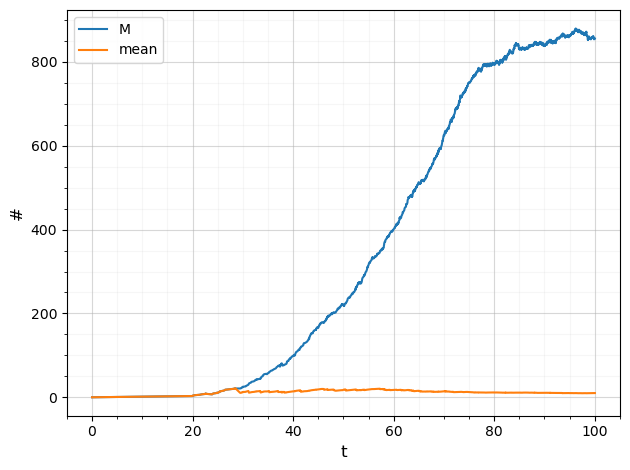

([3, 1706, 562, 282, 6], 10)

In [191]:
plt.plot(times,M_history,label='M')
#plt.plot(times,P_history,label='P')
#plt.plot(times,nc_values,label=f'nc={nc}')
#plt.plot(times,x_values,label=f'{x}')
plt.plot(times,mean_history,label='mean')
#plt.title('Plot',size=12)
plt.xlabel('t',size=12)
plt.ylabel('#',size=12)
plt.legend()
plt.grid(which='major',alpha=0.5)
plt.grid(which='minor',alpha=0.1)
plt.minorticks_on()
plt.tight_layout()
#plt.savefig("images/1.png", dpi=300, bbox_inches="tight")
plt.show()

reactions, round(np.mean(polymers))

(array([  3,   4,   4,   4,   4,   4,   5,   7,   8,   8,  10,  10,  11,
         11,  11,  12,  12,  13,  13,  15,  22,  23,  25,  32,  34,  36,
         37,  37,  39,  39,  54,  79,  88, 129, 149]),
 992)

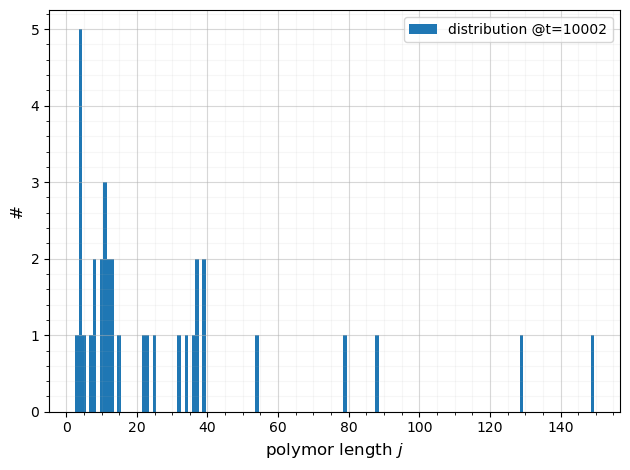

In [129]:
plt.hist(polymers,bins=range(np.min(polymers),np.max(polymers)+2),align="left", label=f'distribution @t={round(t)}')
plt.xlabel('polymor length $j$',size=12)
plt.ylabel('#',size=12)
plt.legend()
plt.grid(which='major',alpha=0.5)
plt.grid(which='minor',alpha=0.1)
plt.minorticks_on()
plt.tight_layout()

np.sort(polymers), sum(polymers)



In [150]:
a = [2]
b = a.copy()
b

[2]

In [ ]:
space implementation
other than gillispie
branching/second nucleation surpression/treatment